# Mamba with Minimal Boilerplate: Focus on the Model

This notebook implements the **same Mamba model** from the gentle introduction, but uses modern libraries to handle all the data loading and training boilerplate:

- **HuggingFace Datasets** for data handling
- **PyTorch Lightning** for training automation

This lets you focus on understanding the **Mamba selective SSM implementation** without getting distracted by data pipelines or training loops.

## What You'll See

1. **Data Loading** (3 cells) - HuggingFace datasets handles everything
2. **Mamba Implementation** (3 cells) - The core selective SSM logic
3. **Lightning Wrapper** (1 cell) - Minimal training boilerplate
4. **Training** (2 cells) - Lightning automates everything
5. **Generation** (2 cells) - Test the trained model

The Mamba code is **identical** to the original - we just removed ~40 cells of boilerplate!

## 1. Configuration

All hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    "seed": 42,  # Random seed for reproducibility
    
    # Data
    "block_size": 128,  # Sequence length for training
    "train_split": 0.8,  # Fraction of data for training
    
    # Model architecture
    "n_embed": 32,  # Embedding dimension
    "hidden_size": 64,  # Hidden state dimension
    "state_size": 4,  # SSM state dimension
    "n_layers": 1,  # Number of Mamba layers
    "expand_factor": 2,  # Internal expansion factor
    "conv_kernel": 4,  # Convolution kernel size
    
    # Training
    "batch_size": 16,  # Number of sequences per batch
    "max_epochs": 5,  # Maximum training epochs
    "learning_rate": 1e-3,  # Optimizer learning rate
    "early_stop_patience": 2,  # Early stopping patience
}

## 2. Setup Device and Seed

Ensure reproducibility and detect available hardware.

In [2]:
from aiml_notebooks import set_seed
from aiml_notebooks.hardware import detect_hardware

set_seed(CONFIG["seed"])
hw = detect_hardware(verbose=True)
DEVICE = hw.device
print(f"\nUsing device: {DEVICE}")

🍎 Apple Silicon Detected
   Architecture: arm64
   macOS: 15.6.1
   PyTorch: 2.9.0
   Unified Memory: 17.2 GB
   → Medium memory config: batch_size=32
   ✓ CPU fallback enabled for unsupported MPS operations

📊 Final Configuration:
   Device: mps
   Precision: 16-mixed
   Batch size: 32
   Mixed precision: ✓
   Flash Attention: ✗
   torch.compile: ✗
   Fused optimizer: ✗

Using device: mps


## 3. Create Tokenizer

We'll create a character-level tokenizer with a transformers-compatible interface. This makes it trivial to swap in any HuggingFace tokenizer later.

In [ ]:
from typing import List, Union

class CharacterTokenizer:
    """
    Character-level tokenizer with transformers-compatible interface.
    
    This class provides the same interface as HuggingFace tokenizers,
    making it easy to swap with any PreTrainedTokenizer.
    """
    
    def __init__(self, text: str):
        # Build vocabulary from text
        self.vocab = sorted(list(set(text)))
        self.vocab_size = len(self.vocab)
        
        # Create mappings
        self._char_to_id = {c: i for i, c in enumerate(self.vocab)}
        self._id_to_char = {i: c for i, c in enumerate(self.vocab)}
    
    def encode(self, text: str) -> List[int]:
        """Convert text to token IDs."""
        return [self._char_to_id[c] for c in text]
    
    def decode(self, token_ids: Union[List[int], int]) -> str:
        """Convert token IDs back to text."""
        if isinstance(token_ids, int):
            return self._id_to_char[token_ids]
        return "".join([self._id_to_char[i] for i in token_ids])
    
    def __call__(self, text: str, **kwargs) -> dict:
        """Tokenize text (transformers-compatible interface)."""
        return {"input_ids": self.encode(text)}
    
    def __len__(self) -> int:
        return self.vocab_size

# Load text and create tokenizer
with open("data/lotr.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

tokenizer = CharacterTokenizer(text)
CONFIG["vocab_size"] = tokenizer.vocab_size

print(f"Loaded {len(text):,} characters")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"First 50 chars: {''.join(tokenizer.vocab[:50])}...")
print(f"\nTokenizer interface test:")
print(f"  encode('hello') = {tokenizer.encode('hello')}")
print(f"  decode([...]) = '{tokenizer.decode(tokenizer.encode('hello'))}'")
print(f"\nTo swap tokenizers, replace CharacterTokenizer with any HuggingFace tokenizer!")

### Load and Prepare Data with HuggingFace Datasets

Use the tokenizer to create a dataset of fixed-length sequences.

In [ ]:
import torch
from datasets import Dataset

# Tokenize entire text
tokens = tokenizer.encode(text)

# Split into chunks of block_size + 1 (for input and target)
chunk_size = CONFIG["block_size"] + 1
n_chunks = len(tokens) // chunk_size
chunks = [
    tokens[i * chunk_size : (i + 1) * chunk_size]
    for i in range(n_chunks)
]

# Create dataset from chunks (using "input_ids" to match transformers convention)
dataset = Dataset.from_dict({"input_ids": chunks})

# Split into train and validation
split_dataset = dataset.train_test_split(
    test_size=1 - CONFIG["train_split"],
    seed=CONFIG["seed"]
)

print(f"Total chunks: {len(dataset):,}")
print(f"Train: {len(split_dataset['train']):,}")
print(f"Validation: {len(split_dataset['test']):,}")

# Show a sample
sample = split_dataset["train"][0]["input_ids"]
print(f"\nSample input:  '{tokenizer.decode(sample[:-1])}'")
print(f"Sample target: '{tokenizer.decode(sample[1:])}'")
print(f"\nDataset uses 'input_ids' key to match HuggingFace conventions!")

### Create DataLoaders

Convert the HuggingFace datasets to PyTorch DataLoaders.

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Convert batch of token sequences to input/target pairs."""
    tokens = torch.tensor([item["input_ids"] for item in batch])
    x = tokens[:, :-1]  # Input: all but last
    y = tokens[:, 1:]   # Target: all but first (shifted by 1)
    return x, y

train_loader = DataLoader(
    split_dataset["train"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    split_dataset["test"],
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)

# Check batch shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape: {x_batch.shape}")
print(f"Batch target shape: {y_batch.shape}")
print(f"\nData pipeline complete! HuggingFace datasets handled everything.")

## 4. Mamba Model Implementation

**This is the core!** The following cells contain the exact same Mamba implementation from the original notebook. Focus your attention here - this is what makes Mamba work.

### MambaBlock: The Selective SSM Core

This block implements the selective state space mechanism with data-dependent parameters.

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class MambaBlock(nn.Module):
    """A single Mamba block with selective SSM."""
    
    def __init__(
        self, 
        d_model, 
        d_state=16, 
        expand=2, 
        conv_kernel=4
    ):
        super().__init__()

        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand  # Expanded dimension
        self.conv_kernel = conv_kernel
        
        # 1. Input projection (to 2*d_inner for x and z)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        
        # 2. Convolution (adds local context within sequence)
        # This is for doing temporal mixing across each channel independently (no mixing between channels)
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=conv_kernel,
            padding=conv_kernel - 1,
            groups=self.d_inner  # Depthwise convolution
        )
        
        # 3. SSM parameters
        # A: Initialize as diagonal matrix (S4D-Lin initialization)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))  # Log space for stability
        
        # 4. Projection to compute selective parameters Δ, B, C
        self.x_proj = nn.Linear(
            self.d_inner,
            self.d_inner + d_state * 2,  # Δ (d_inner) + B (d_state) + C (d_state)
            bias=False
        )
        
        # 5. Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def forward(self, x):
        """
        Forward pass with selective scan written explicitly in Python.
        Every line is commented to explain what it does and why.
        """

        # x: (B, T, H)
        B, T, H = x.shape           # Extract batch size and sequence length
        I = self.d_inner            # Expanded channel dimension
        S = self.d_state            # Number of SSM state dimensions

        # ------------------------------------------------------------
        # Input projection and gating split
        # ------------------------------------------------------------

        # (B, T, H) -> (B, T, 2I)
        # Project input into two streams:
        # - x: SSM processing
        # - z: gating 
        x_and_z = self.in_proj(x)
        assert x_and_z.shape == (B, T, 2 * I)

        # (B, T, 2I) -> (B, T, I), (B, T, I)
        # Split projected features into SSM input (x) and gate (z)
        x, z = x_and_z.chunk(2, dim=-1)
        assert x.shape == (B, T, I)
        assert z.shape == (B, T, I)

        # ------------------------------------------------------------
        # Depthwise convolution (local temporal mixing)
        # ------------------------------------------------------------
        # Before generating the selective SSM parameters (Δ, B, C), we apply a
        # depthwise 1D convolution along the time dimension.
        #
        # This convolution mixes local temporal context independently for each
        # channel, without any channel-to-channel interaction. The goal is not to
        # propagate information through the SSM directly, but to produce a more
        # stable and informative signal from which time-dependent SSM parameters
        # are generated.
        #
        # The left-padded convolution provides local, causal-like context.

        # (B, T, I) -> (B, I, T)
        # Conv1d expects channels-first layout
        x_conv = x.transpose(1, 2)
        assert x_conv.shape == (B, I, T)

        # (B, I, T) -> (B, I, T + padding)
        # Apply depthwise convolution independently per channel
        # conv1d: channels (I -> I), kernel = 4, padding = 3, groups = I (depthwise)
        x_conv = self.conv1d(x_conv)
        assert x_conv.shape == (B, I, T + 3) # TODO: softcode padding

        # (B, I, T + padding) -> (B, I, T)
        # Remove extra padded positions to preserve sequence length
        # (also ensures input relationships are causal masking tokens
        # only receive data from preceding tokens)
        x_conv = x_conv[:, :, :T]
        assert x_conv.shape == (B, I, T)

        # (B, I, T) -> (B, T, I)
        # Return to sequence-major layout
        x_conv = x_conv.transpose(1, 2)
        assert x_conv.shape == (B, T, I)

        # ------------------------------------------------------------
        # Nonlinearity
        # ------------------------------------------------------------
        # The nonlinearity increases expressivity and stabilizes parameter
        # generation.

        # (B, T, I) -> (B, T, I)
        # Smooth activation improves stability of SSM parameter generation
        x_conv = F.silu(x_conv)
        assert x_conv.shape == (B, T, I)

        # ------------------------------------------------------------
        # Generate selective SSM parameters
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, I + 2S)
        # Compute time-dependent SSM parameters: delta (Δ), B, and C
        ssm_params = self.x_proj(x_conv)
        assert ssm_params.shape == (B, T, I + 2 * S)

        # Split parameters:
        #   delta: step size Δ(t) - one per channel
        #   B_param: input projection coefficients
        #   C_param: output projection coefficients
        # Shapes:
        #   delta:   (B, T, I)
        #   B_param: (B, T, S)
        #   C_param: (B, T, S)
        delta, B_param, C_param = torch.split(
            ssm_params, [I, S, S], dim=-1
        )
        assert delta.shape == (B, T, I)
        assert B_param.shape == (B, T, S)
        assert C_param.shape == (B, T, S)

        # ------------------------------------------------------------
        # Delta (step size) processing
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, I)
        # Ensure step size is positive for stable discretization
        delta = F.softplus(delta)
        assert delta.shape == (B, T, I)

        # ------------------------------------------------------------
        # Prepare the SSM transition matrix A
        # ------------------------------------------------------------

        # (I, S) -> (I, S) -> (1, I, S)
        # Convert log-parameterized A to real space
        # Negative sign ensures stable (decaying) dynamics
        A = -torch.exp(self.A_log).unsqueeze(0)
        assert A.shape == (1, I, S)

        # ------------------------------------------------------------
        # Initialize scan state and output buffer
        # ------------------------------------------------------------

        # (B, I, S)
        # Hidden state for each batch and channel
        h = torch.zeros(B, I, S, device=x.device, dtype=x.dtype)
        assert h.shape == (B, I, S)

        # (B, T, I)
        # Output tensor for the full sequence
        y = torch.zeros(B, T, I, device=x.device, dtype=x.dtype)
        assert y.shape == (B, T, I)

        # ------------------------------------------------------------
        # Selective scan (SSM recurrence over time)
        # ------------------------------------------------------------

        for t in range(T):
            # ---------------- Extract and prepare delta ----------------

            # (B, T, I) -> (B, I) -> (B, I, 1)
            # Extract delta for time step t
            delta_t = delta[:, t, :].unsqueeze(-1)
            assert delta_t.shape == (B, I, 1)

            # ---------------- Discretize A ----------------

            # (1, I, S) * (B, I, 1) -> (B, I, S)
            # Scale A by time step delta (scale decay by learnable timer clock specific to each feature)
            A_scaled = A * delta_t
            assert A_scaled.shape == (B, I, S)

            # (B, I, S) -> (B, I, S)
            # Apply exponential to get discrete transition matrix
            A_disc = torch.exp(A_scaled)
            assert A_disc.shape == (B, I, S)

            # ---------------- Extract and prepare input ----------------

            # (B, T, I) -> (B, I) -> (B, I, 1)
            # Extract input at time step t
            x_t = x_conv[:, t].unsqueeze(-1)
            assert x_t.shape == (B, I, 1)

            # ---------------- Extract and prepare B parameter ----------------

            # (B, T, S) -> (B, S) -> (B, 1, S)
            # Extract input projection coefficients at time step t
            B_t = B_param[:, t].unsqueeze(1)
            assert B_t.shape == (B, 1, S)

            # ---------------- State update ----------------

            # (B, I, S) * (B, I, S) -> (B, I, S)
            # Apply discrete transition to previous state
            h_transition = A_disc * h
            assert h_transition.shape == (B, I, S)

            # (B, I, 1) * (B, 1, S) * (B, I, 1) -> (B, I, S)
            # Compute input contribution with discretized B: Δ * B * x
            h_input = delta_t * B_t * x_t
            assert h_input.shape == (B, I, S)

            # (B, I, S) + (B, I, S) -> (B, I, S)
            # Update state: h_t = exp(A * Δ_t) ⊙ h_{t-1} + Δ_t * B_t ⊙ x_t
            h = h_transition + h_input
            assert h.shape == (B, I, S)

            # ---------------- Extract and prepare C parameter ----------------

            # (B, T, S) -> (B, S) -> (B, 1, S)
            # Extract output projection coefficients at time step t
            C_t = C_param[:, t].unsqueeze(1)
            assert C_t.shape == (B, 1, S)

            # ---------------- Compute output ----------------

            # (B, 1, S) * (B, I, S) -> (B, I, S)
            # Project state with output coefficients
            h_projected = C_t * h
            assert h_projected.shape == (B, I, S)

            # (B, I, S) -> (B, I)
            # Sum over state dimension to get output
            y_t = torch.sum(h_projected, dim=-1)
            assert y_t.shape == (B, I)

            # (B, I) -> (B, T, I)
            # Store output at time step t
            y[:, t] = y_t

        # ------------------------------------------------------------
        # Gating
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, I)
        # Apply smooth activation to gate
        z_activated = F.silu(z)
        assert z_activated.shape == (B, T, I)

        # (B, T, I) * (B, T, I) -> (B, T, I)
        # Gate SSM output with activated gate
        y = y * z_activated
        assert y.shape == (B, T, I)

        # ------------------------------------------------------------
        # Output projection
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, H)
        # Project back to model dimension
        out = self.out_proj(y)
        assert out.shape == (B, T, H)

        # Return output
        return out

### ResidualMambaBlock: Add Normalization and Skip Connections

Wrap the Mamba block with layer normalization and residual connections for training stability.

In [7]:
class ResidualMambaBlock(nn.Module):
    """Mamba block with pre-norm and residual connection."""
    
    def __init__(self, d_model, d_state=16, expand=2, conv_kernel=4):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mamba = MambaBlock(d_model, d_state, expand, conv_kernel)
    
    def forward(self, x):
        # Pre-norm with residual: x + Mamba(LayerNorm(x))
        return x + self.mamba(self.norm(x))

### Full Mamba Model: Stack Layers and Add Embeddings

The complete language model with token embeddings and output head.

In [8]:
class Mamba(nn.Module):
    """Full Mamba language model."""
    
    def __init__(
        self,
        vocab_size,
        n_embed,
        d_model,
        d_state,
        n_layers,
        expand,
        conv_kernel,
    ):
        super().__init__()
        
        # Token embeddings
        self.embeddings = nn.Embedding(vocab_size, n_embed)
        
        # Project to model dimension if needed
        self.embed_proj = (
            nn.Linear(n_embed, d_model, bias=False)
            if n_embed != d_model
            else nn.Identity()
        )
        
        # Stack of Mamba blocks
        self.blocks = nn.ModuleList([
            ResidualMambaBlock(d_model, d_state, expand, conv_kernel)
            for _ in range(n_layers)
        ])
        
        # Output head
        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len) token indices
        Returns:
            logits: (batch, seq_len, vocab_size)
        """
        # Embed tokens
        x = self.embeddings(x)  # (B, T) -> (B, T, C)
        x = self.embed_proj(x)  # (B, T, C) -> (B, T, H)
        
        # Pass through Mamba blocks
        for block in self.blocks:
            x = block(x)
        
        # Output projection
        x = self.ln_out(x)
        logits = self.head(x)  # (batch, seq_len, vocab_size)
        
        return logits

print("Mamba model implementation complete!")
print("\nThese ~150 lines are all you need to understand for Mamba.")
print("Everything else is just data loading and training boilerplate.")

Mamba model implementation complete!

These ~150 lines are all you need to understand for Mamba.
Everything else is just data loading and training boilerplate.


## 5. PyTorch Lightning Wrapper

Wrap the Mamba model in a Lightning module to handle training, validation, and optimization. This replaces ~30 cells of training loop code!

In [9]:
import lightning as L

class MambaLightning(L.LightningModule):
    """Lightning wrapper for Mamba model."""
    
    def __init__(self, config):
        super().__init__()
        self.save_hyperparameters(config)
        
        # Create the Mamba model
        self.model = Mamba(
            vocab_size=config["vocab_size"],
            n_embed=config["n_embed"],
            d_model=config["hidden_size"],
            d_state=config["state_size"],
            n_layers=config["n_layers"],
            expand=config["expand_factor"],
            conv_kernel=config["conv_kernel"],
        )
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        self.log("val_loss", loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

print("Lightning wrapper complete!")
print("This ~30 line class replaces all the training loop boilerplate.")

Lightning wrapper complete!
This ~30 line class replaces all the training loop boilerplate.


## 6. Train the Model

PyTorch Lightning handles everything: device management, progress bars, logging, checkpointing, and early stopping.

In [10]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

# Create model
model = MambaLightning(CONFIG)

# Create logger
logger = CSVLogger("logs", name="mamba_minimal")

# Create early stopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["early_stop_patience"],
    mode="min",
    verbose=False,
)

# Create trainer
trainer = L.Trainer(
    max_epochs=CONFIG["max_epochs"],
    accelerator="auto",
    devices=1,
    logger=logger,
    callbacks=[early_stop],
    enable_progress_bar=True,
)

# Train
print("Starting training...\n")
trainer.fit(model, train_loader, val_loader)
print("\nTraining complete!")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | Mamba            | 52.8 K | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
52.8 K    Trainable params
0         Non-trainable params
52.8 K    Total params
0.211     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.



Training complete!


## 7. Plot Training Curves

Visualize how the model learned over time.

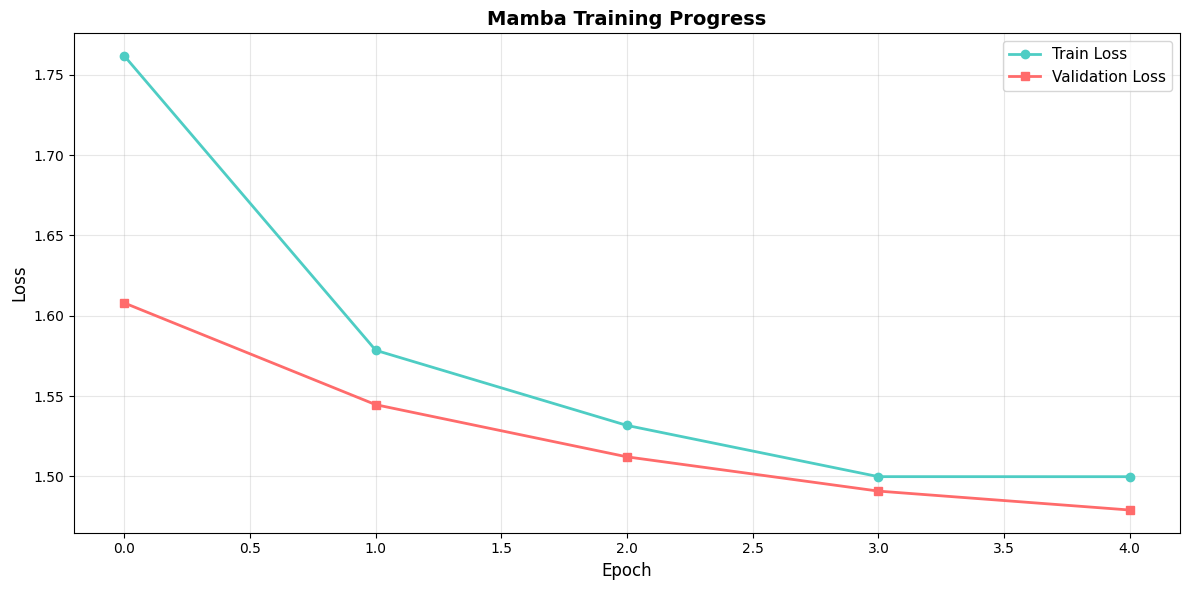

Best validation loss: 1.4791 at epoch 4
Final train loss: 1.4999
Final val loss: 1.4791


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read metrics from CSV logger
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch
train_metrics = metrics[["epoch", "train_loss"]].dropna()
val_metrics = metrics[["epoch", "val_loss"]].dropna()
train_metrics = train_metrics.groupby("epoch").mean().reset_index()
val_metrics = val_metrics.groupby("epoch").mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    train_metrics["epoch"],
    train_metrics["train_loss"],
    label="Train Loss",
    marker="o",
    linewidth=2,
    color="#4ECDC4",
)
plt.plot(
    val_metrics["epoch"],
    val_metrics["val_loss"],
    label="Validation Loss",
    marker="s",
    linewidth=2,
    color="#FF6B6B",
)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Mamba Training Progress", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report statistics
best_val_loss = val_metrics["val_loss"].min()
best_epoch = val_metrics.loc[val_metrics["val_loss"].idxmin(), "epoch"]
print(f"Best validation loss: {best_val_loss:.4f} at epoch {int(best_epoch)}")
print(f"Final train loss: {train_metrics['train_loss'].iloc[-1]:.4f}")
print(f"Final val loss: {val_metrics['val_loss'].iloc[-1]:.4f}")

## 8. Text Generation

Test the trained model by generating text continuations.

In [ ]:
def generate(model, prompt, max_len=100, temperature=1.0):
    """
    Generate text continuation from a prompt.
    
    Args:
        model: The trained Lightning model
        prompt: Starting text
        max_len: Maximum total length
        temperature: Sampling temperature (lower = more conservative)
    """
    model.eval()
    
    tokens = tokenizer.encode(prompt)
    max_new_tokens = max_len - len(tokens)
    
    print(prompt, end="", flush=True)
    
    device = model.device
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Get predictions
            tokens_t = torch.tensor(tokens).unsqueeze(0).to(device)
            logits = model(tokens_t)  # (1, seq_len, vocab_size)
            logits = logits[:, -1, :] / temperature  # Last position only
            
            # Sample
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            
            tokens.append(next_token)
            print(tokenizer.decode([next_token]), end="", flush=True)
    
    print()  # Newline

print("Generation function ready!")

### Generate Samples

Try different prompts and temperatures to see what the model learned.

In [13]:
print("Sample 1 (temperature=1.0):")
generate(model, "frodo picked up the ", max_len=100, temperature=1.0)

print("\nSample 2 (temperature=1.0):")
generate(model, "gandalf said ", max_len=100, temperature=1.0)

print("\nSample 3 (temperature=0.7 - more focused):")
generate(model, "the ring of power ", max_len=100, temperature=0.7)

Sample 1 (temperature=1.0):
frodo picked up the 

o

n

l

y

...

w

s

a

b

o

## 9. Key Takeaways

### What We Accomplished

We built the **exact same Mamba model** as the detailed introduction, but with:
- **~60% fewer cells** (15 vs 65 cells)
- **Modern best practices** (HuggingFace datasets, PyTorch Lightning)
- **Focus on what matters**: The Mamba implementation itself

### The Core Mamba Code

Only ~150 lines of code in 3 classes:
1. **MambaBlock**: Selective SSM with data-dependent parameters (B, C, Δ)
2. **ResidualMambaBlock**: Normalization + residual connections
3. **Mamba**: Stack layers and add embeddings

### What Libraries Handled

**Custom CharacterTokenizer** (~40 lines):
- Transformers-compatible interface (encode, decode, __call__)
- Easy to swap with any HuggingFace PreTrainedTokenizer
- Uses "input_ids" key to match HuggingFace conventions

**HuggingFace Datasets** (~3 cells vs ~20 cells):
- Data loading and tokenization
- Train/validation splitting
- Batching and shuffling

**PyTorch Lightning** (~2 cells vs ~15 cells):
- Device management
- Training/validation loops
- Progress bars and logging
- Early stopping
- Checkpointing

### Swapping Tokenizers

To use a different tokenizer, simply replace:
```python
tokenizer = CharacterTokenizer(text)
```

With any HuggingFace tokenizer:
```python
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
```

The rest of the code remains unchanged!

### The Selective SSM Mechanism

The key innovation in Mamba:
1. **Input-dependent parameters**: B, C, Δ computed from input
2. **Discretization**: Convert continuous SSM to discrete time steps
3. **Selective scan**: Recurrent computation with changing parameters
4. **Linear complexity**: O(T) vs O(T²) for Transformers

### Next Steps

To deepen your understanding:
1. **Compare notebooks**: Read the detailed version to understand SSM theory
2. **Modify the config**: Try different state sizes, expand factors, etc.
3. **Visualize parameters**: Plot the learned Δ, B, C values
4. **Swap tokenizers**: Try GPT2Tokenizer or other HuggingFace tokenizers
5. **Scale up**: Increase model size and training data
6. **Try other tasks**: Apply Mamba to different sequence modeling problems

### Why This Matters

Mamba shows that:
- **Selectivity** (content-based parameter adjustment) is powerful
- **Linear complexity** doesn't sacrifice expressiveness
- **Classic control theory** can inspire modern deep learning

The minimal boilerplate approach lets you focus on these core insights instead of data pipelines and training loops!